In [36]:
import pandas as pd
import matplotlib as plt

In [33]:
data ={
    'city': ['Kathmandu','Dharan','Biratnagar'],
    'population':[2000,150,1700]   
}

df=pd.DataFrame(data)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   city        3 non-null      object
 1   population  3 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes
None


<Axes: ylabel='population'>

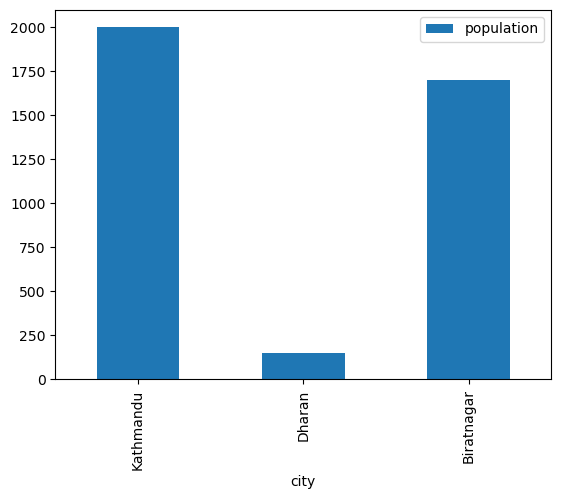

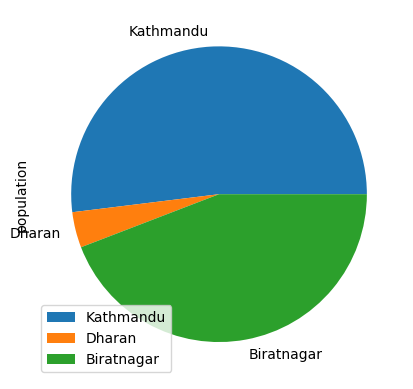

In [34]:
# x=data['city']
# y=data['populataion']
df.plot.bar(x='city',y='population')
df.plot.pie(y='population',labels=df['city'])

In [37]:
df_students = pd.DataFrame({
    'StudentID':[1,2,3],
    'Name': ['Ram','Sita','Hari']
    })

df_marks = pd.DataFrame({
    'StudentID':[1,2,4],
    'Marks': [55,87,64]
})
print(df_students)
print(df_marks)

   StudentID  Name
0          1   Ram
1          2  Sita
2          3  Hari
   StudentID  Marks
0          1     55
1          2     87
2          4     64


In [38]:
merged_inner = pd.merge(df_students,df_marks, on='StudentID',how='inner')
print(merged_inner)

   StudentID  Name  Marks
0          1   Ram     55
1          2  Sita     87


In [39]:
merged_outer = pd.merge(df_students,df_marks, on='StudentID',how='outer')
print(merged_outer)

   StudentID  Name  Marks
0          1   Ram   55.0
1          2  Sita   87.0
2          3  Hari    NaN
3          4   NaN   64.0


In [40]:
merged_right = pd.merge(df_students,df_marks, on='StudentID',how='right')
print(merged_right)

   StudentID  Name  Marks
0          1   Ram     55
1          2  Sita     87
2          4   NaN     64


In [46]:
merged_left = pd.merge(df_students,df_marks, on='StudentID',how='left')
print(merged_left)

   StudentID  Name  Marks
0          1   Ram   55.0
1          2  Sita   87.0
2          3  Hari    NaN


In [48]:
df_A= pd.DataFrame({
    'Temperature': [20,24,25]
},index=['Day1','Day2','Day3'])

df_B= pd.DataFrame({
    'Humidity':[60,64,68]
},index=['Day1','Day2','Day4'])

print(df_A)
print(df_B)

      Temperature
Day1           20
Day2           24
Day3           25
      Humidity
Day1        60
Day2        64
Day4        68


In [76]:
outer_join=df_A.join(df_B , how='outer')
print(outer_join)

      Temperature  Humidity
Day1         20.0      60.0
Day2         24.0      64.0
Day3         25.0       NaN
Day4          NaN      68.0


In [78]:
df_wide = pd.DataFrame({
    'Name':['Ram','Sita'],
    'Maths':[60,87],
    'Science':[88,65]
})
print(df_wide)

   Name  Maths  Science
0   Ram     60       88
1  Sita     87       65


In [81]:
df_long=pd.melt(
    df_wide,
    id_vars=['Name'],
    var_name='Subject',
    value_name='Score'
)
print(df_long)

   Name  Subject  Score
0   Ram    Maths     60
1  Sita    Maths     87
2   Ram  Science     88
3  Sita  Science     65


In [88]:
df_original = df_long.pivot(
    index='Name',
    columns='Subject',
    values='Score'
)
print(df_original)

Subject  Maths  Science
Name                   
Ram         60       88
Sita        87       65


In [89]:
df_stacked=df_long.stack()
print(df_stacked)

0  Name           Ram
   Subject      Maths
   Score           60
1  Name          Sita
   Subject      Maths
   Score           87
2  Name           Ram
   Subject    Science
   Score           88
3  Name          Sita
   Subject    Science
   Score           65
dtype: object


In [90]:
df_unstacked = df_stacked.unstack()
print(df_unstacked)

   Name  Subject Score
0   Ram    Maths    60
1  Sita    Maths    87
2   Ram  Science    88
3  Sita  Science    65


In [ ]:
pivot_tbl = pd.pivot_table(
    df_exam,
    index='Name',
    columns='Subject',
    values='Score',
    aggfunc='count'
)
print(pivot_tbl) 

In [103]:
df=pd.read_csv("data.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Roll     4 non-null      int64  
 1   Name     3 non-null      object 
 2   Address  3 non-null      object 
 3   Age      3 non-null      float64
 4   Gender   2 non-null      object 
dtypes: float64(1), int64(1), object(3)
memory usage: 292.0+ bytes
None


In [104]:
# check missing values
df.isna().sum()

Roll       0
Name       1
Address    1
Age        1
Gender     2
dtype: int64

In [ ]:
# drop rows with any missing value
new_df= df.dropna()     #use axis=1 -- to drop columns
print(new_df)

   Roll  Name  Address   Age Gender
3     4  Hari  Sunsari  43.0   Male


In [112]:
df['Address']=df['Address'].fillna("Unknown")
df['Age']=df['Age'].fillna(df['Age'].mean())
df

,Roll,Name,Address,Age,Gender
0,1,Ram,Biratnager,33.333333,Male
1,2,Shyam,Unknown,34.000000,NaN
2,3,NaN,Dharan,23.000000,NaN
3,4,Hari,Sunsari,43.000000,Male
